# qMINOS vs Gurobi

All analyses done for solver selection

In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

## Table of Contents
- [Solver Performance and Solution Comparison](#solver-performance-and-solution-comparison)
- [FVA Results](#fva-results)

## Solver Performance and Solution Comparison

In [2]:
import numpy as np
import pandas as pd
from scripts.solver_selection.compare_solvers import summarize, total_summary, common_columns 
import matplotlib.pyplot as plt
import seaborn as sns

# plt.style.use("bmh")

In [3]:
q_aerob = pd.read_pickle(DATA / "solver_selection/qminos_aerob.pkl")
q_anaerob = pd.read_pickle(DATA / "solver_selection/qminos_anaerob.pkl")

g_aerob = pd.read_pickle(DATA / "solver_selection/gurobi_aerob.pkl")
g_anaerob = pd.read_pickle(DATA / "solver_selection/gurobi_anaerob.pkl")

totalt antall miljøer i hver kilde, kan hente ut med get exchanges etc
```text
C: 286
N: 179
S: 28
P: 64

**SUMMARY**

In [4]:
summary = pd.DataFrame([
    summarize(q_aerob, "qMINOS", "aerobic"),
    summarize(q_anaerob, "qMINOS", "anaerobic"),
    summarize(g_aerob, "Gurobi", "aerobic"),
    summarize(g_anaerob, "Gurobi", "anaerobic"),
])
summary

,condition,solver,C_solved,C_total,C_success_rate,N_solved,N_total,N_success_rate,P_solved,P_total,P_success_rate,S_solved,S_total,S_success_rate
0,aerobic,qMINOS,180,286,0.629371,91,179,0.508380,49,64,0.765625,11,28,0.392857
1,anaerobic,qMINOS,143,286,0.500000,75,179,0.418994,49,64,0.765625,5,28,0.178571
2,aerobic,Gurobi,167,286,0.583916,89,179,0.497207,48,64,0.750000,10,28,0.357143
3,anaerobic,Gurobi,139,286,0.486014,74,179,0.413408,47,64,0.734375,5,28,0.178571


In [5]:
print("Sovled Aerobic Environments: ")
common_columns(g_aerob, q_aerob)

print("************************************\nSolved Anaerobic Environments:")
common_columns(g_anaerob, q_anaerob)


Sovled Aerobic Environments: 
Gurobi columns: 315
qMINOS columns: 332
-------------------------
Only in Gurobi (0): set()
Only in Qminos (17):  {'thrp_P', 'g3pe_C', 'cmp_C', 'acmum_N', 'duri_C', 'thr__L_C', 'g3pc_C', 'man_C', '3cmp_C', 'glcur_C', 'ethso3_C', 'ocdcea_C', 'g3pi_C', 'cgly_S', 'malt_C', 'LalaLglu_C', 'udpg_N'}
************************************
Solved Anaerobic Environments:
Gurobi columns: 266
qMINOS columns: 273
-------------------------
Only in Gurobi (0): set()
Only in Qminos (7):  {'udpg_C', 'progly_N', 'mal__L_C', 'trp__L_C', 'glcr_C', 'acgam1p_P', '23cgmp_P'}


In [6]:
print(f"Total feasible solutions computed by QMINOS: {q_aerob.shape[1] + q_anaerob.shape[1]}")
print(f"Total feasible solutions computed by Gurobi: {g_aerob.shape[1] + g_anaerob.shape[1]}")

Total feasible solutions computed by QMINOS: 605
Total feasible solutions computed by Gurobi: 581


In [7]:
time_g_c = pd.read_csv(DATA/'solver_selection/hundered_sims/solver_results_gurobi.csv')

In [10]:
time_g_1 = pd.read_csv(DATA/'solver_selection/solver_results_gurobi_True.csv')
time_g_0 = pd.read_csv(DATA/'solver_selection/solver_results_gurobi_False.csv')

time_q_1 = pd.read_csv(DATA/'solver_selection/solver_results_qminos_True.csv')
time_q_0 = pd.read_csv(DATA/'solver_selection/solver_results_qminos_False.csv')

In [11]:
gurobi_time = pd.concat([time_g_c, time_g_1, time_g_0])
qminos_time = pd.concat([time_q_1, time_q_0])

In [16]:
gurobi_time.sort_values(by='time', ascending=True)

,source,mu,time
21,EX_peamn_e,0.728143,53.630473
102,EX_g3ps_e,0.614397,53.667155
131,EX_sbt__D_e,0.833084,54.075195
83,EX_ser__D_e,0.747679,58.069552
40,EX_r5p_e,0.759244,59.675390
...,...,...,...
220,EX_malthx_e,0.634570,407.476375
181,EX_LalaDgluMdap_e,0.167582,417.703708
128,EX_gam6p_e,0.847168,453.143822
248,EX_ser__L_e,0.422656,462.074953


In [26]:
gurobi_time['time'].mean()

np.float64(148.37184910750733)

In [19]:
qminos_time.sort_values(by='time', ascending=False)

,source,mu,time
309,EX_ethso3_e,0.004972,3623.480296
129,EX_ethso3_e,0.004972,3577.299956
115,EX_acmana_e,0.546091,2006.385892
114,EX_LalaDgluMdap_e,0.163064,1847.873537
183,EX_chtbs_e,0.563262,1810.855183
...,...,...,...
207,EX_3cmp_e,0.640296,363.199542
0,EX_acmana_e,0.808406,299.192618
9,EX_glyc2p_e,0.794670,287.100969
90,EX_thrp_e,0.761951,277.493649


In [25]:
qminos_time['time'].mean()

np.float64(968.7110467719127)

**Aligning dataframes:**

In [4]:
# Keep only conditions present in BOTH solvers
common_aerob = g_aerob.columns.intersection(q_aerob.columns)
common_anaerob = g_anaerob.columns.intersection(q_anaerob.columns)

# Align dataframes
g_aerob_aligned = g_aerob[common_aerob]
q_aerob_aligned = q_aerob[common_aerob]

g_anaerob_aligned = g_anaerob[common_anaerob]
q_anaerob_aligned = q_anaerob[common_anaerob]

In [85]:
q_aerob_aligned.drop(columns="Reaction").min().min()

np.float64(-110.88885892222298)

In [86]:
q_anaerob_aligned.drop(columns="Reaction").min().min()

np.float64(-243.35463824868683)

In [90]:
g_aerob_aligned.drop(columns="Reaction").max().max()

np.float64(1000.0000000655454)

In [89]:
g_anaerob_aligned.drop(columns="Reaction").max().max()

np.float64(1000.0)

# **Comparing Computations**

**Flux distributions**

In [6]:
color_map = sns.color_palette("GnBu", as_cmap=True)

g_raw_a = g_aerob_aligned.select_dtypes(include='number').to_numpy().flatten()
q_raw_a = q_aerob_aligned.select_dtypes(include='number').to_numpy().flatten()

g_raw_an = g_anaerob_aligned.select_dtypes(include='number').to_numpy().flatten()
q_raw_an = q_anaerob_aligned.select_dtypes(include='number').to_numpy().flatten()

In [26]:
def summarize_fluxes(dfs, solver_name, tol=None):
    fluxes = pd.concat([df.drop(columns=["Reaction"]) for df in dfs], axis=1)
    
    nonzero_per_solution = (fluxes != 0).sum(axis=0)
    nonzero_tol_per_solution = (fluxes.abs() >= tol).sum(axis=0)
    
    all_nonzero_mask = fluxes != 0
    below_tol = (fluxes[all_nonzero_mask].abs() < tol).sum().sum()
    total_nonzero = all_nonzero_mask.sum().sum()

    print(f"=== {solver_name} ===")
    print(f"Mean nonzero fluxes per solution:            {nonzero_per_solution.mean():.2f} ± {nonzero_per_solution.std():.2f}")
    print(f"Mean nonzero fluxes per solution (tol-adj):  {nonzero_tol_per_solution.mean():.2f} ± {nonzero_tol_per_solution.std():.2f}")
    print(f"Fraction of nonzero fluxes below tolerance:  {below_tol/total_nonzero:.2}")

In [27]:
summarize_fluxes([q_aerob_aligned, q_anaerob_aligned], "qMINOS", tol=1e-20)

=== qMINOS ===
Mean nonzero fluxes per solution:            2337.93 ± 50.15
Mean nonzero fluxes per solution (tol-adj):  2337.83 ± 50.13
Fraction of nonzero fluxes below tolerance:  4e-05


In [29]:
summarize_fluxes([g_aerob_aligned, g_anaerob_aligned], "Gurobi", tol=1e-6)

=== Gurobi ===
Mean nonzero fluxes per solution:            2146.49 ± 181.90
Mean nonzero fluxes per solution (tol-adj):  1124.05 ± 77.32
Fraction of nonzero fluxes below tolerance:  0.48


In [60]:
def summarize_fluxes(dfs, solver_name, tol=1e-6, high_mag=[1, 10, 200, 800, 1000]):
    fluxes = pd.concat([df.drop(columns=["Reaction"]) for df in dfs], axis=1)
    
    nonzero_per_solution = (fluxes != 0).sum(axis=0)
    nonzero_tol_per_solution = (fluxes.abs() >= tol).sum(axis=0)
    
    all_nonzero_mask = fluxes != 0
    below_tol = (fluxes[all_nonzero_mask].abs() < tol).sum().sum()
    total_nonzero = all_nonzero_mask.sum().sum()

    print(f"=== {solver_name} ===")
    print(f"Fraction of nonzero fluxes per solution {nonzero_per_solution.mean()/len(fluxes):.3f}")
    print(f"Fraction of nonzero fluxes below tolerance per solution {nonzero_tol_per_solution.mean()/len(fluxes):.3f}")
    print(f"Mean nonzero fluxes per solution:            {nonzero_per_solution.mean():.3f} ± {nonzero_per_solution.std():.3f}")
    print(f"Mean nonzero fluxes per solution (tol-adj):  {nonzero_tol_per_solution.mean():.3f} ± {nonzero_tol_per_solution.std():.3f}")
    print(f"Fraction of nonzero fluxes below tolerance:  {below_tol/total_nonzero:.3%}")
    print(f"--- High-magnitude fluxes (mean per solution) ---")
    for threshold in high_mag:
        mean_high = (fluxes.abs() >= threshold).sum(axis=0).mean()
        print(f"  |v| >= {threshold}: {mean_high:.3f} ({mean_high/len(fluxes):.4f}) ")

In [61]:
summarize_fluxes([q_aerob_aligned, q_anaerob_aligned], "qMINOS", tol=1e-20)

=== qMINOS ===
Fraction of nonzero fluxes per solution 0.185
Fraction of nonzero fluxes below tolerance per solution 0.185
Mean nonzero fluxes per solution:            2337.927 ± 50.146
Mean nonzero fluxes per solution (tol-adj):  2337.834 ± 50.127
Fraction of nonzero fluxes below tolerance:  0.004%
--- High-magnitude fluxes (mean per solution) ---
  |v| >= 1: 54.351 (0.0043) 
  |v| >= 10: 20.715 (0.0016) 
  |v| >= 200: 0.005 (0.0000) 
  |v| >= 800: 0.000 (0.0000) 
  |v| >= 1000: 0.000 (0.0000) 


In [62]:
summarize_fluxes([g_aerob_aligned, g_anaerob_aligned], "Gurobi", tol=1e-6)

=== Gurobi ===
Fraction of nonzero fluxes per solution 0.170
Fraction of nonzero fluxes below tolerance per solution 0.089
Mean nonzero fluxes per solution:            2146.492 ± 181.902
Mean nonzero fluxes per solution (tol-adj):  1124.054 ± 77.320
Fraction of nonzero fluxes below tolerance:  47.633%
--- High-magnitude fluxes (mean per solution) ---
  |v| >= 1: 61.147 (0.0048) 
  |v| >= 10: 28.111 (0.0022) 
  |v| >= 200: 8.568 (0.0007) 
  |v| >= 800: 8.563 (0.0007) 
  |v| >= 1000: 6.473 (0.0005) 


### Plotting

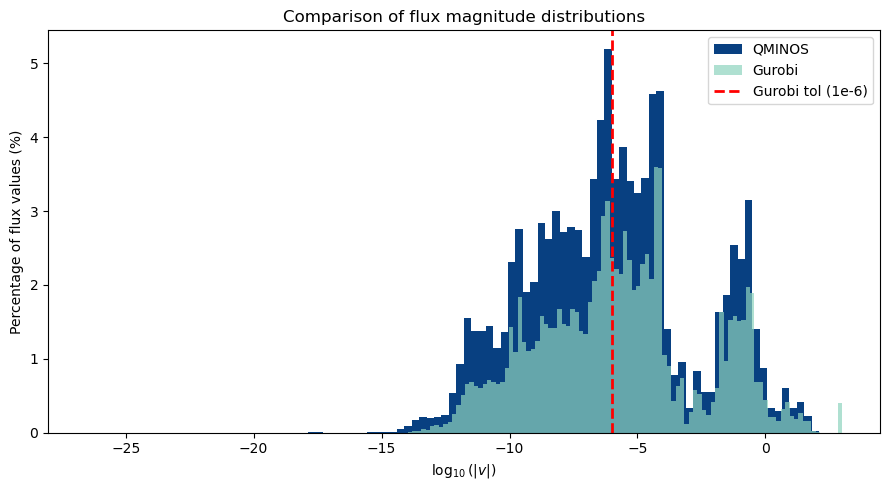

In [ ]:
g_raw = np.concatenate([g_raw_a, g_raw_an])
q_raw = np.concatenate([q_raw_a, q_raw_an])

g_plot = np.abs(g_raw)
q_plot = np.abs(q_raw)

g_plot = g_plot[g_plot > 0]
q_plot = q_plot[q_plot > 0]

weights_g = np.ones_like(g_plot) / len(g_plot) * 100
weights_q = np.ones_like(q_plot) / len(q_plot) * 100

plt.figure(figsize=(9, 5))

plt.hist(np.log10(q_plot),
         bins=100,
         weights=weights_q,
         label='QMINOS',
         color=color_map(1.0))

plt.hist(np.log10(g_plot),
         bins=100,
         weights=weights_g,
         label='Gurobi',
         color=color_map(0.45),
         alpha=0.7)

plt.axvline(-6, color='red', linestyle='--', linewidth=2,
            label='Gurobi tol (1e-6)')

plt.xlabel(r'$\log_{10}(|v|)$')
plt.ylabel('Percentage of flux values (%)')
plt.title('Comparison of flux magnitude distributions')
plt.legend()

plt.tight_layout()
plt.show()

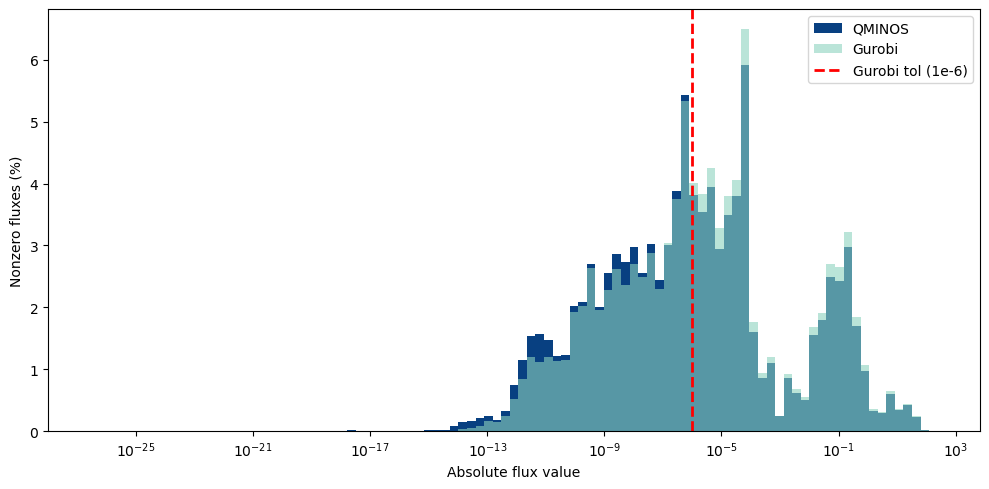

In [7]:

g_raw = np.concatenate([
    g_aerob_aligned.select_dtypes(include='number').to_numpy().flatten(),
    g_anaerob_aligned.select_dtypes(include='number').to_numpy().flatten()
])

q_raw = np.concatenate([
    q_aerob_aligned.select_dtypes(include='number').to_numpy().flatten(),
    q_anaerob_aligned.select_dtypes(include='number').to_numpy().flatten()
])


g_plot = np.abs(g_raw)
q_plot = np.abs(q_raw)

g_plot = g_plot[g_plot > 0]
q_plot = q_plot[q_plot > 0]


weights_g = np.ones_like(g_plot) / len(g_plot) * 100
weights_q = np.ones_like(q_plot) / len(q_plot) * 100


min_flux = min(q_plot.min(), g_plot.min())
max_flux = max(q_plot.max(), g_plot.max())
bins = np.logspace(np.log10(min_flux), np.log10(max_flux), 100)

plt.figure(figsize=(10, 5))
bins = np.logspace(np.log10(q_plot.min()), np.log10(q_plot.max()), 100)

plt.hist(q_plot, bins=bins, weights=weights_q, alpha=1.0, label='QMINOS', color=color_map(1.0))
plt.hist(g_plot, bins=bins, weights=weights_g, alpha=0.6, label='Gurobi', color=color_map(0.45))

plt.axvline(1e-6, linestyle='--', linewidth=2, label='Gurobi tol (1e-6)', color='red')
# plt.axvline(1e-20, linestyle=':', linewidth=2, color='red', label='QMINOS tol (1e-20)')


# plt.xlabel(r'$\log_{10}(|v|)$')
# plt.xlabel(r'$|v|$')
plt.xlabel('Absolute flux value')
plt.xscale('log')
plt.ylabel('Nonzero fluxes (%)')
# plt.yscale('log')
# plt.title("Distribution of nonzero fluxes")
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
print("Gurobi fluxes >= 800:", np.sum(np.abs(g_raw) >= 800))
print("QMINOS fluxes >= 100:", np.sum(np.abs(q_raw) >= 100))

Gurobi fluxes >= 800: 4958
QMINOS fluxes >= 100: 91


In [ ]:
print("Gurobi fluxes < 0.5:", np.sum(np.abs(g_raw) < 0.5))
print("QMINOS fluxes < 0.5:", np.sum(np.abs(q_raw) < 0.5))

In [108]:
print("Gurobi fluxes < tol:", np.sum(np.abs(g_raw) < 1e-20))
print("QMINOS fluxes < tol:", np.sum(np.abs(q_raw) < 1e-8))

Gurobi fluxes < tol: 6084426
QMINOS fluxes < tol: 6363504


In [ ]:
print("Gurobi fluxes between 0-1:", 1e-20 < np.sum(np.abs(g_raw) <= 1))
print("QMINOS fluxes between 0-1:", 1e-8 < np.sum(np.abs(q_raw) <= 1))

Gurobi fluxes >= 1: True
QMINOS fluxes >= 1: True


In [56]:
print("Gurobi fluxes >= 1:", np.sum(np.abs(g_raw) >= 1))
print("QMINOS fluxes >= 1:", np.sum(np.abs(q_raw) >= 1))

Gurobi fluxes >= 1: 35404
QMINOS fluxes >= 1: 31469


In [51]:
np.sum(np.abs(g_raw))

np.float64(5385022.168458197)

In [52]:
np.sum(np.abs(q_raw))

np.float64(469152.3630385718)

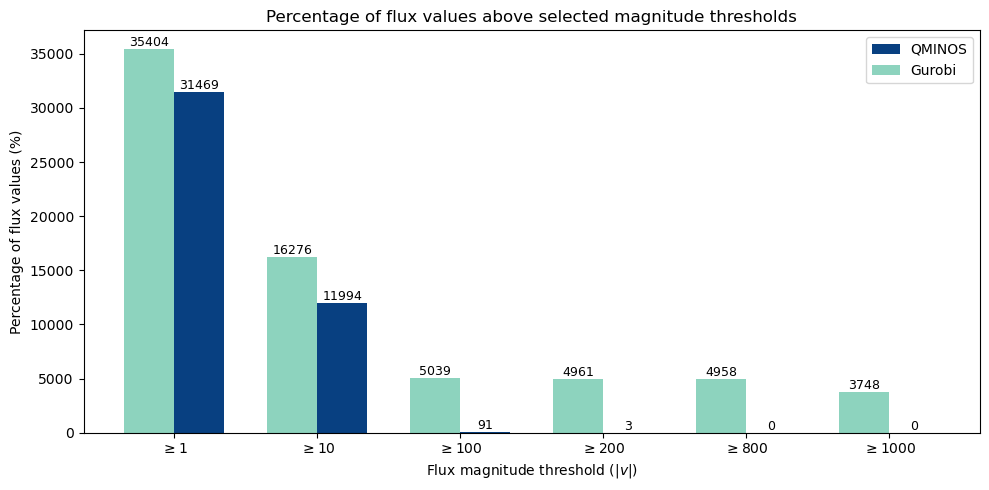

In [ ]:
thresholds = [1, 10, 100, 200, 800, 1000]

g_counts = [np.sum(np.abs(g_raw) >= t) for t in thresholds]
q_counts = [np.sum(np.abs(q_raw) >= t) for t in thresholds]

g_total = len(g_raw)
q_total = len(q_raw)

# g_counts = [np.sum(np.abs(g_raw) >= t) / g_total * 100 for t in thresholds]
# q_counts = [np.sum(np.abs(q_raw) >= t) / q_total * 100 for t in thresholds]

x = np.arange(len(thresholds))
width = 0.35

plt.figure(figsize=(10, 5))

bars_q = plt.bar(x + width/2, q_counts, width, label="QMINOS", color=color_map(1.0))
bars_g = plt.bar(x - width/2, g_counts, width, label="Gurobi", color=color_map(0.45))

labels = [
    r'$\geq 1$',
    r'$\geq 10$',
    r'$\geq 100$',
    r'$\geq 200$',
    r'$\geq 800$',
    r'$\geq 1000$'
]

plt.xticks(x, labels)
plt.xlabel(r'Flux magnitude threshold ($|v|$)')
plt.ylabel("Percentage of flux values (%)")
plt.title('Percentage of flux values above selected magnitude thresholds')
plt.legend()

for bar in bars_q:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )


for bar in bars_g:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=9
    )


plt.tight_layout()
plt.show()

In [137]:
g_abs = np.abs(g_raw)
q_abs = np.abs(q_raw)

g_zero = np.sum(g_abs == 0)
g_tiny = np.sum((g_abs > 0) & (g_abs < 1e-6))
g_active = np.sum(g_abs >= 1e-6)

q_zero = np.sum(q_abs == 0)
q_tiny = np.sum((q_abs > 0) & (q_abs < 1e-6))
q_active = np.sum(q_abs >= 1e-6)

print("Gurobi:", g_zero, g_tiny, g_active)
print("QMINOS:", q_zero, q_tiny, q_active)

Gurobi: 6084426 591992 650827
QMINOS: 6221219 733760 675986


In [122]:
import numpy as np

print(np.finfo(np.float64))

Machine parameters for float64
---------------------------------------------------------------
precision = 15   resolution = 1e-15
machep = -52   eps =        2.220446049250313e-16
negep =  -53   epsneg =     1.1102230246251565e-16
minexp = -1022   tiny =       2.2250738585072014e-308
maxexp = 1024   max =        1.7976931348623157e+308
nexp =   11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 5e-324
---------------------------------------------------------------



### Objective Value

In [8]:
q_mu = q_aerob.head(1)
g_mu = g_aerob.head(1)

In [9]:
g_mu_aligned = g_mu.reindex(columns=q_mu.columns)

gurobi_growth = g_mu_aligned.select_dtypes(include=np.number).iloc[0]
qminos_growth = q_mu.select_dtypes(include=np.number).iloc[0]

rel_diff = abs((gurobi_growth - qminos_growth) / qminos_growth)
rel_diff.replace([np.inf, -np.inf], np.nan, inplace=True)

rel_diff_nonzero = rel_diff[rel_diff > 0]

In [10]:
q_mu_a = q_aerob.head(1)
g_mu_a = g_aerob.head(1)

g_mu_a_aligned = g_mu_a.reindex(columns=q_mu_a.columns)

gurobi_a = g_mu_a_aligned.select_dtypes(include=np.number).iloc[0]
qminos_a = q_mu_a.select_dtypes(include=np.number).iloc[0]

rel_diff_a = abs((gurobi_a - qminos_a) / qminos_a)
rel_diff_a.replace([np.inf, -np.inf], np.nan, inplace=True)
rel_diff_a = rel_diff_a[rel_diff_a > 0]


q_mu_an = q_anaerob.head(1)
g_mu_an = g_anaerob.head(1)

g_mu_an_aligned = g_mu_an.reindex(columns=q_mu_an.columns)

gurobi_an = g_mu_an_aligned.select_dtypes(include=np.number).iloc[0]
qminos_an = q_mu_an.select_dtypes(include=np.number).iloc[0]

rel_diff_an = abs((gurobi_an - qminos_an) / qminos_an)
rel_diff_an.replace([np.inf, -np.inf], np.nan, inplace=True)
rel_diff_an = rel_diff_an[rel_diff_an > 0]

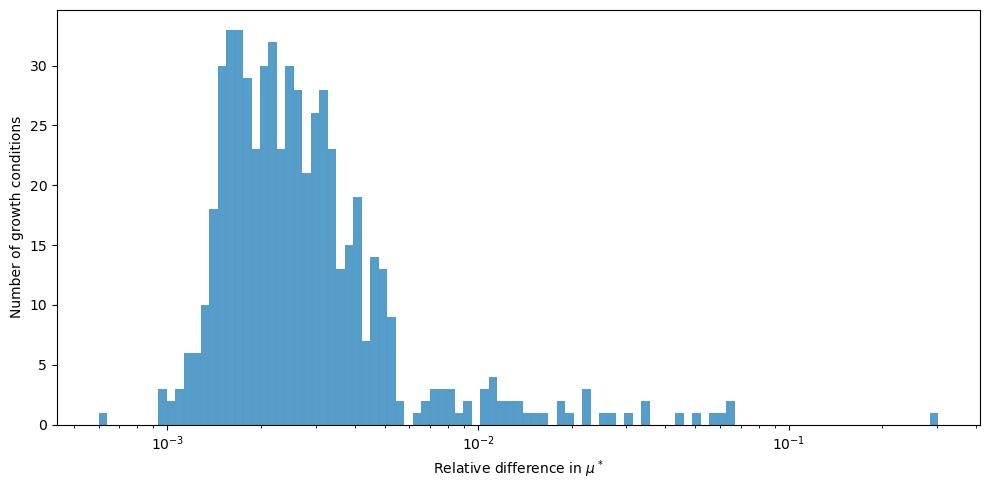

In [11]:
q_mu = pd.concat([q_aerob.head(1), q_anaerob.head(1)], ignore_index=True)
g_mu = pd.concat([g_aerob.head(1), g_anaerob.head(1)], ignore_index=True)


g_mu_aligned = g_mu.reindex(columns=q_mu.columns)


gurobi = g_mu_aligned.select_dtypes(include=np.number).to_numpy().flatten()
qminos = q_mu.select_dtypes(include=np.number).to_numpy().flatten()


rel_diff = np.abs((gurobi - qminos) / qminos)


rel_diff = rel_diff[np.isfinite(rel_diff)] 
rel_diff = rel_diff[rel_diff > 0]


bins = np.logspace(
    np.log10(rel_diff.min()),
    np.log10(rel_diff.max()),
    100
)

plt.figure(figsize=(10, 5))

sns.histplot(rel_diff, bins=bins, color=color_map(0.80))
plt.xscale("log")

plt.xlabel(r"Relative difference in $\mu^*$")
plt.ylabel("Number of growth conditions")
# plt.title("Relative differences between qMINOS and Gurobi objective values")

plt.tight_layout()
plt.show()

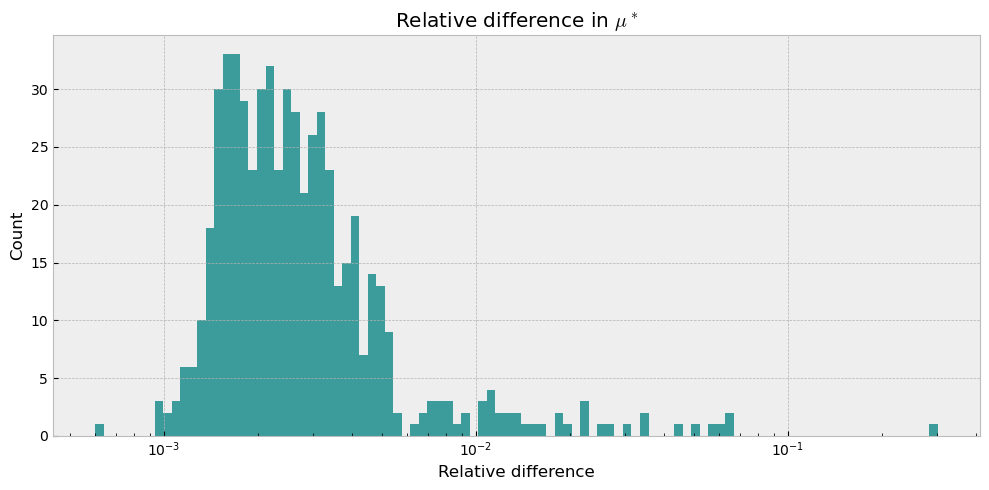

In [ ]:

q_mu = pd.concat([q_aerob.head(1), q_anaerob.head(1)], ignore_index=True)
g_mu = pd.concat([g_aerob.head(1), g_anaerob.head(1)], ignore_index=True)


g_mu_aligned = g_mu.reindex(columns=q_mu.columns)


gurobi = g_mu_aligned.select_dtypes(include=np.number).to_numpy().flatten()
qminos = q_mu.select_dtypes(include=np.number).to_numpy().flatten()


rel_diff = np.abs((gurobi - qminos) / qminos)


rel_diff = rel_diff[np.isfinite(rel_diff)]   
rel_diff = rel_diff[rel_diff > 0]


bins = np.logspace(
    np.log10(rel_diff.min()),
    np.log10(rel_diff.max()),
    100
)

plt.figure(figsize=(10, 5))

sns.histplot(rel_diff, bins=bins, color='teal')
plt.xscale("log")

plt.xlabel("Relative difference")
plt.ylabel("Count")
plt.title(r"Relative difference in $\mu^*$")

plt.tight_layout()
plt.show()

In [50]:
rel_diff.max()

np.float64(0.30242383695655)

In [54]:
print(f"Environment with largest relative difference: {rel_diff.idxmax()} \nDifference: {float(rel_diff.max())}")

Environment with largest relative difference: csn_N 
Difference: 0.30242383695655


In [55]:
print(q_mu['csn_N'])
print(g_mu_aligned['csn_N'])

0    0.824281
Name: csn_N, dtype: float64
0    0.574999
Name: csn_N, dtype: float64


## Biomass Components

### Aerobic:

In [119]:
bm_cols = [
    "protein_biomass_to_biomass",
    "mRNA_biomass_to_biomass",
    "tRNA_biomass_to_biomass",
    "rRNA_biomass_to_biomass",
    "ncRNA_biomass_to_biomass",
    "DNA_biomass_to_biomass",
    "lipid_biomass_to_biomass",
    "constituent_biomass_to_biomass",
    "prosthetic_group_biomass_to_biomass",
    "peptidoglycan_biomass_to_biomass"
]

cols_g = set(g_aerob.columns)
cols_q = set(q_aerob.columns)

only_in_q = cols_q - cols_g

bm_q = q_aerob.drop(columns=only_in_q).set_index("Reaction").T
bm_g = g_aerob.set_index('Reaction').T

bm_g = bm_g[bm_cols]
bm_q = bm_q[bm_cols]

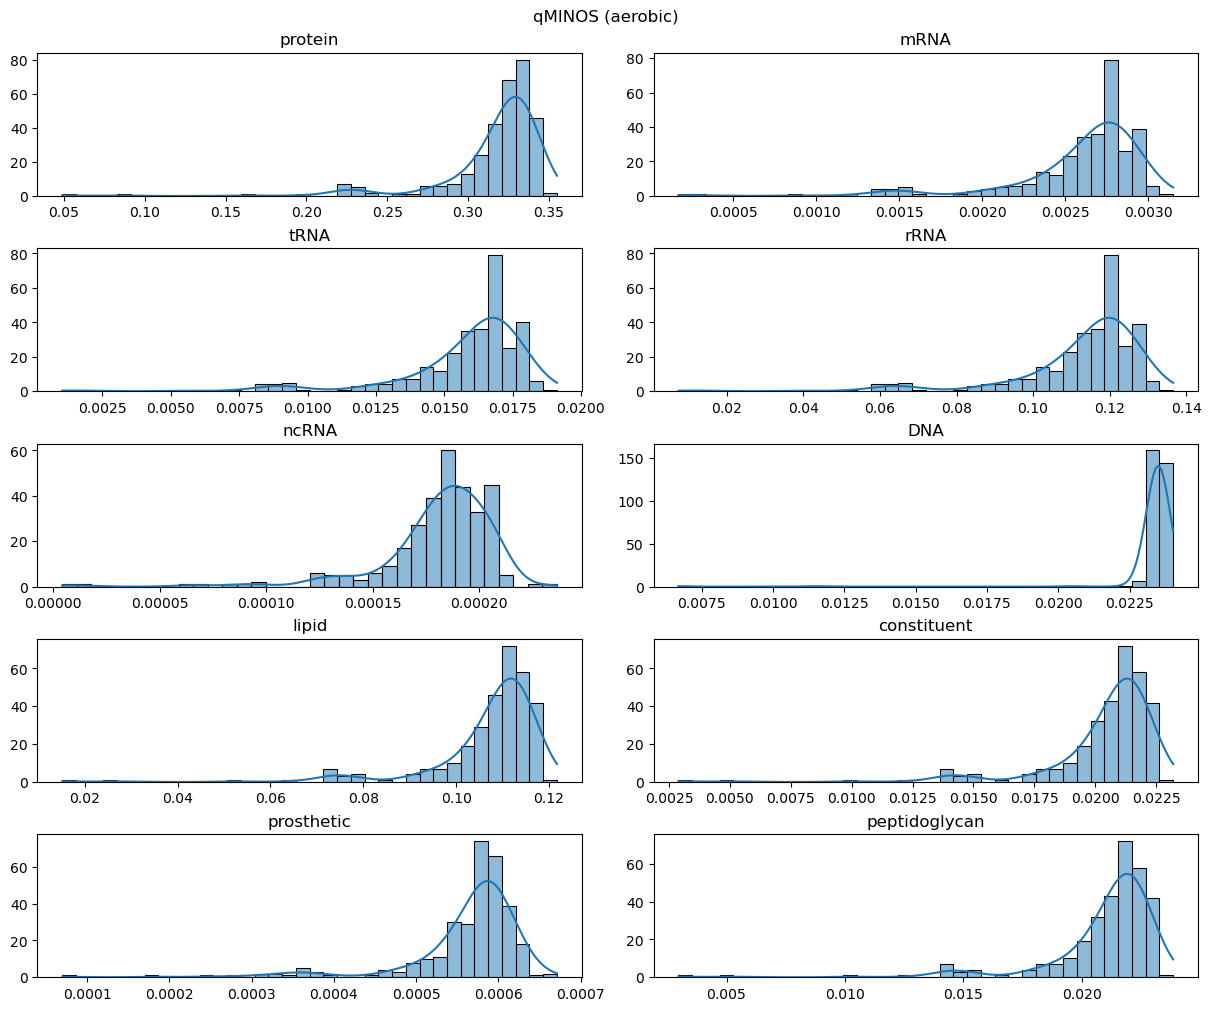

In [ ]:
bm_q.columns = [col.split("_", 1)[0] for col in bm_q.columns]
cols = bm_q.columns


fig, axes = plt.subplots(
    nrows=5, ncols=2, figsize=(12, 10),
    constrained_layout=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(
        bm_q[col],
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")


for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle("qMINOS (aerobic)")
plt.show()


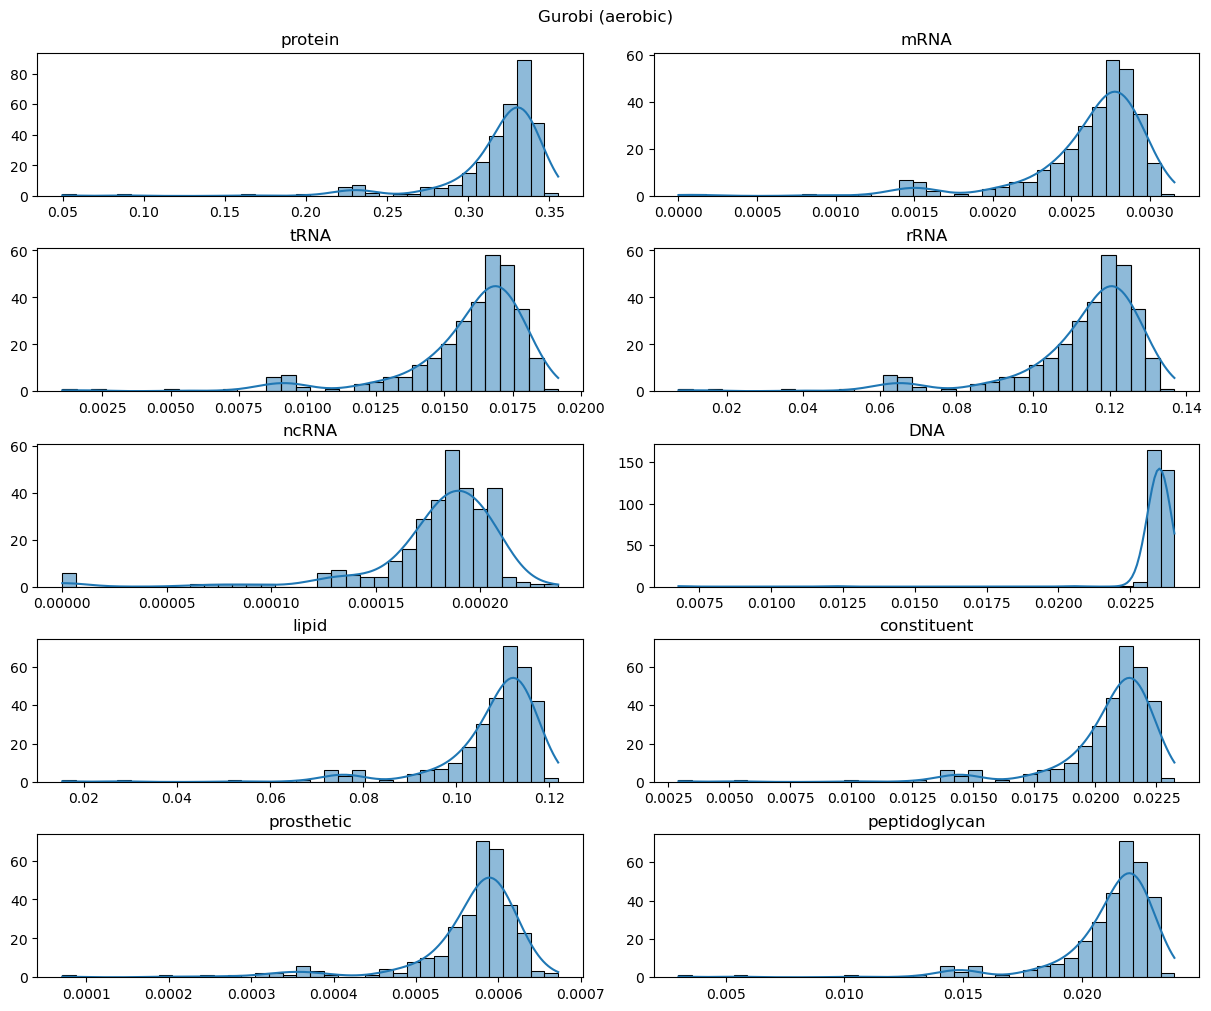

In [ ]:
bm_g.columns = [col.split("_", 1)[0] for col in bm_g.columns]
cols = bm_g.columns


fig, axes = plt.subplots(
    nrows=5, ncols=2, figsize=(12, 10),
    constrained_layout=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(
        bm_g[col],
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")


for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle('Gurobi (aerobic)')
plt.show()

### Anaerobic

In [128]:
cols_g = set(g_anaerob.columns)
cols_q = set(q_anaerob.columns)

only_in_q_an = cols_q - cols_g

bm_q_an = q_aerob.drop(columns=only_in_q_an).set_index("Reaction").T
bm_g_an = g_aerob.set_index('Reaction').T

bm_g_an = bm_g_an[bm_cols]
bm_q_an = bm_q_an[bm_cols]

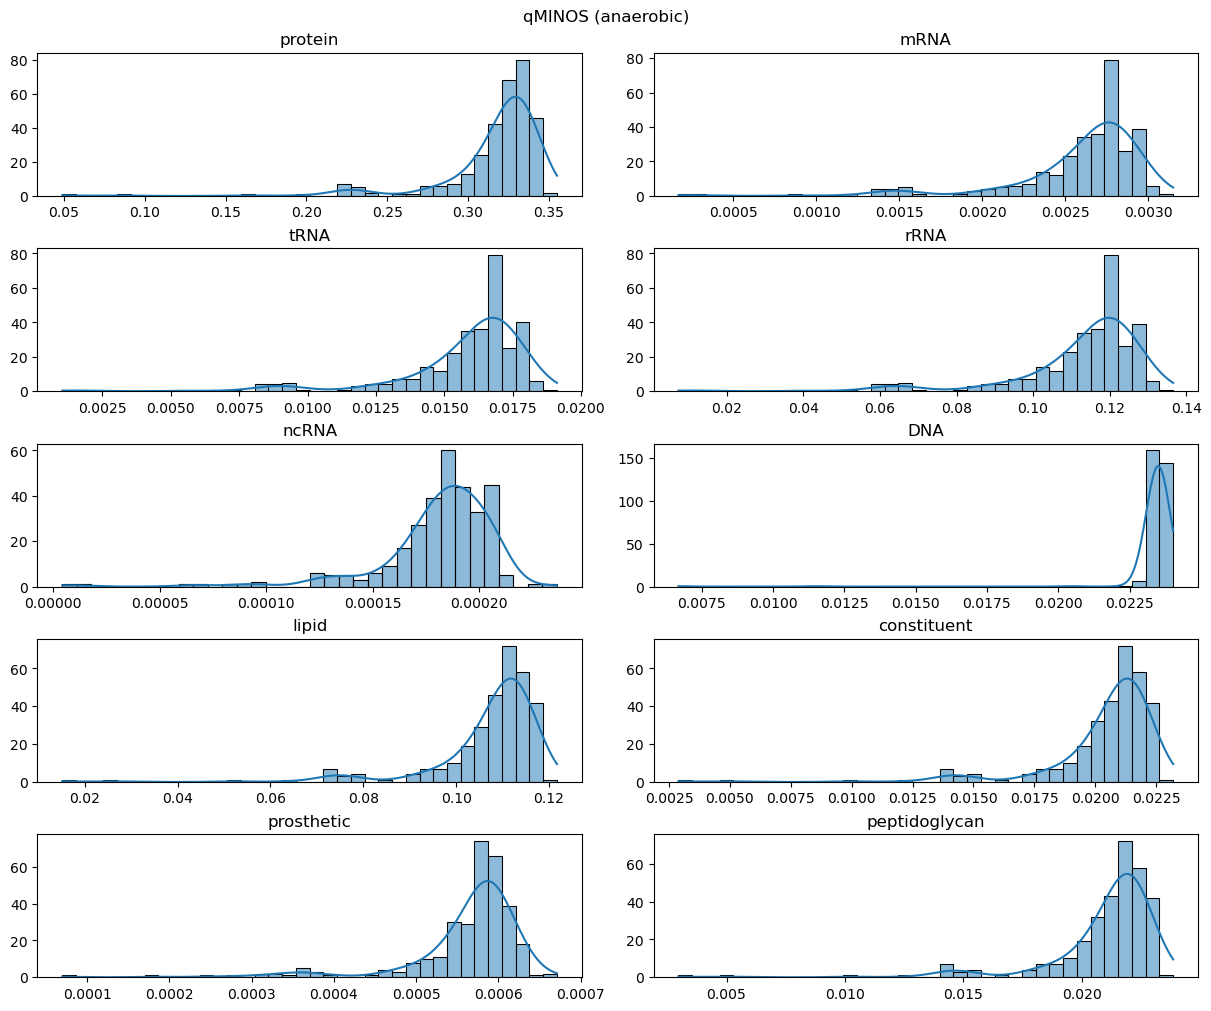

In [ ]:
bm_q_an.columns = [col.split("_", 1)[0] for col in bm_q_an.columns]
cols = bm_q_an.columns


fig, axes = plt.subplots(
    nrows=5, ncols=2, figsize=(12, 10),
    constrained_layout=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(
        bm_q[col],
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")


for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle("qMINOS (anaerobic)")
plt.show()


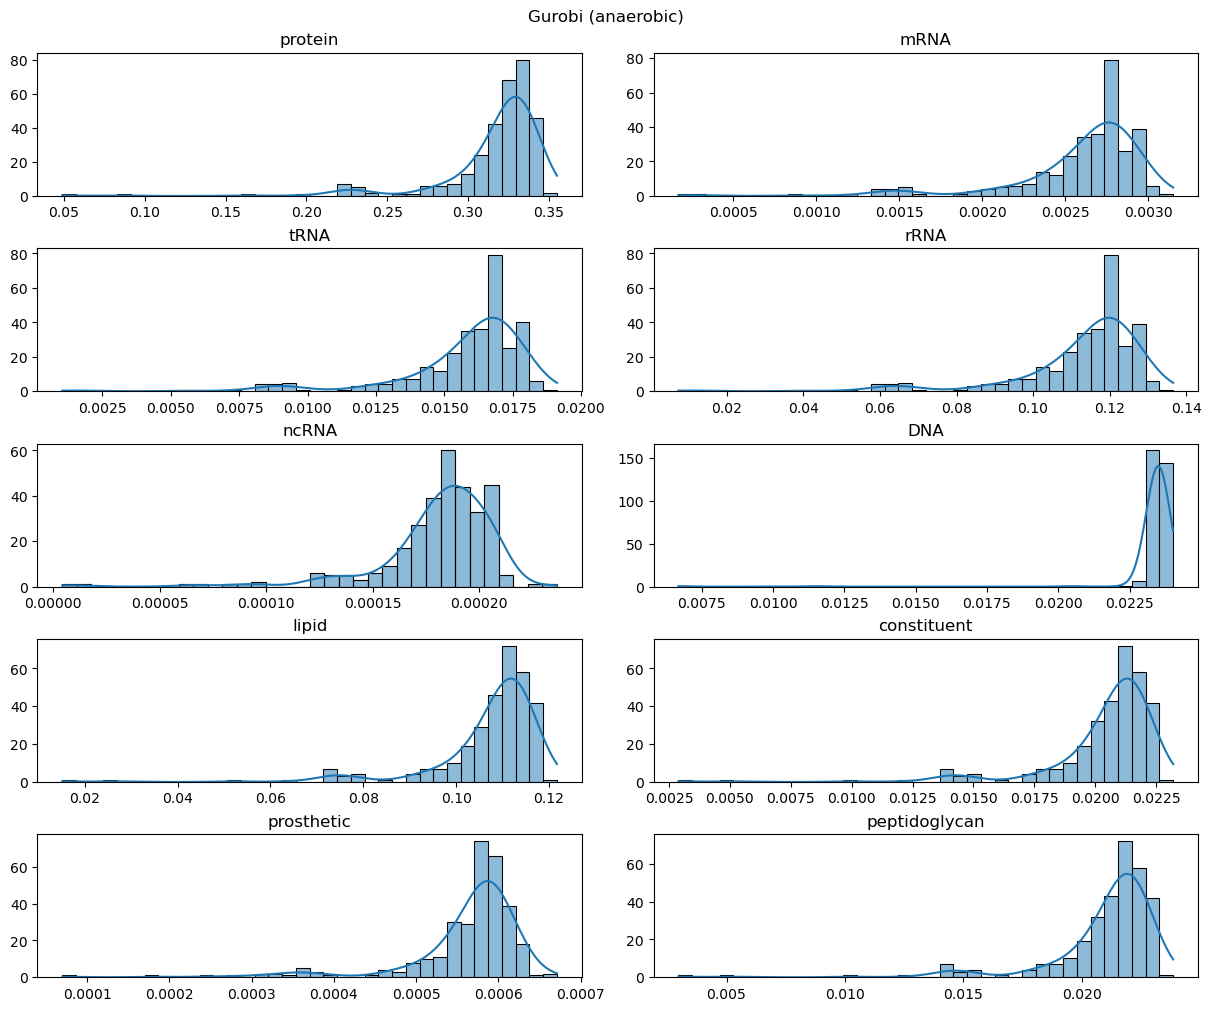

In [ ]:
bm_g_an.columns = [col.split("_", 1)[0] for col in bm_g_an.columns]
cols = bm_g_an.columns


fig, axes = plt.subplots(
    nrows=5, ncols=2, figsize=(12, 10),
    constrained_layout=True
)

axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.histplot(
        bm_q[col],
        kde=True,
        ax=ax
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle("Gurobi (anaerobic)")
plt.show()


# **FVA Results**

*using program written in fva_solvers.py, had to ensure gurobi would run - this was done after the gurboi stability analysis*

In [144]:
carbon_gurobi = pd.read_csv(DATA / "solver_selection/fva_gurobi_carbon.csv")
carbon_qminos = pd.read_csv(DATA / "solver_selection/fva_qminos_carbon.csv")

nitrogen_gurobi = pd.read_csv(DATA / "solver_selection/fva_gurobi_nitrogen.csv")
nitrogen_qminos = pd.read_csv(DATA / "solver_selection/fva_qminos_nitrogen2.csv")

### qMINOS

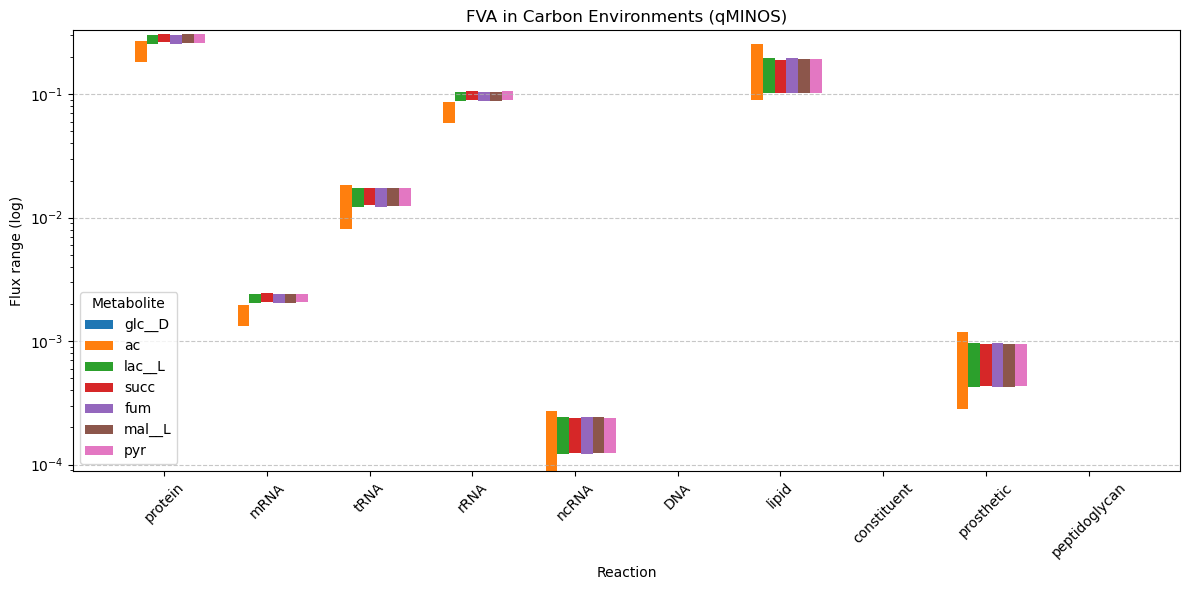

In [145]:
plot_fva(carbon_qminos, 'FVA in Carbon Environments (qMINOS)')

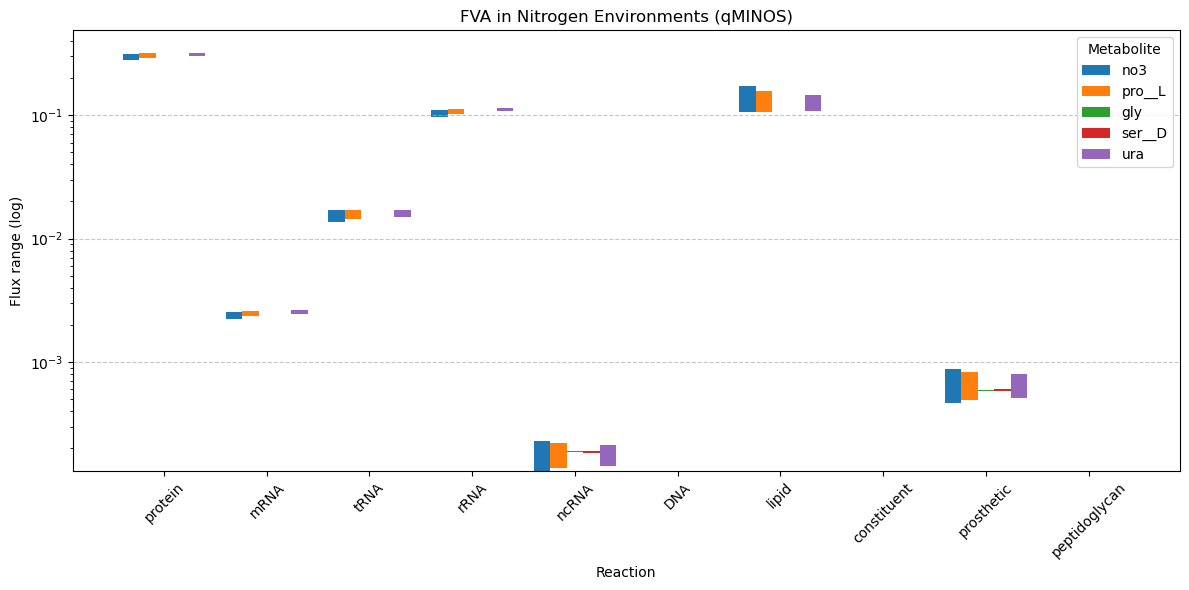

In [146]:
plot_fva(nitrogen_qminos, 'FVA in Nitrogen Environments (qMINOS)')

### Gurobi

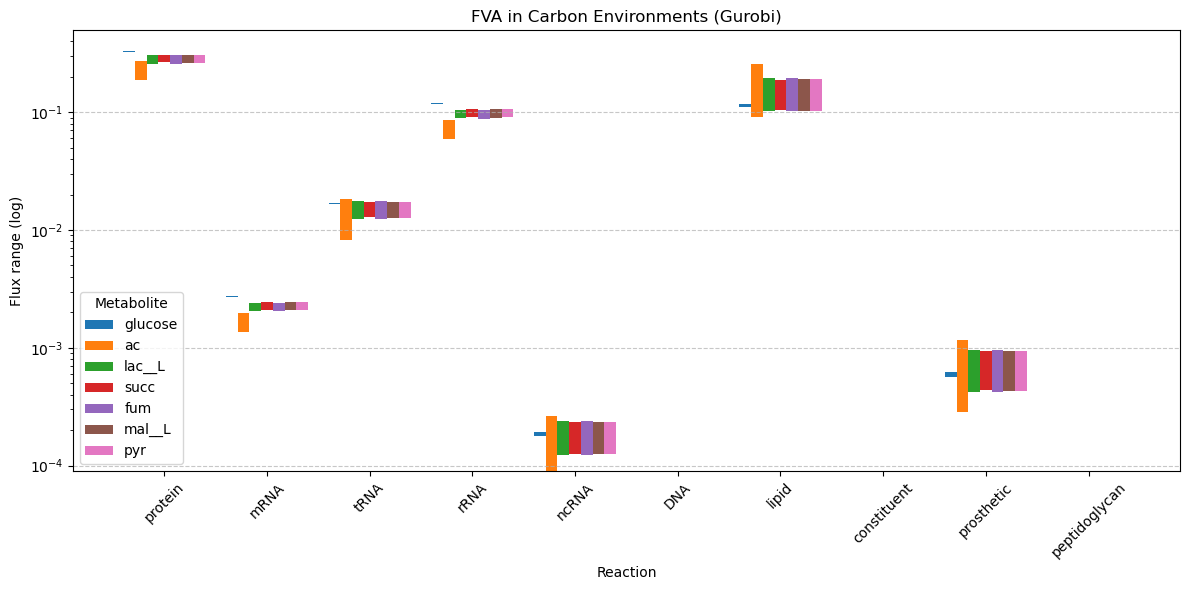

In [141]:
plot_fva(carbon_gurobi, 'FVA in Carbon Environments (Gurobi)')

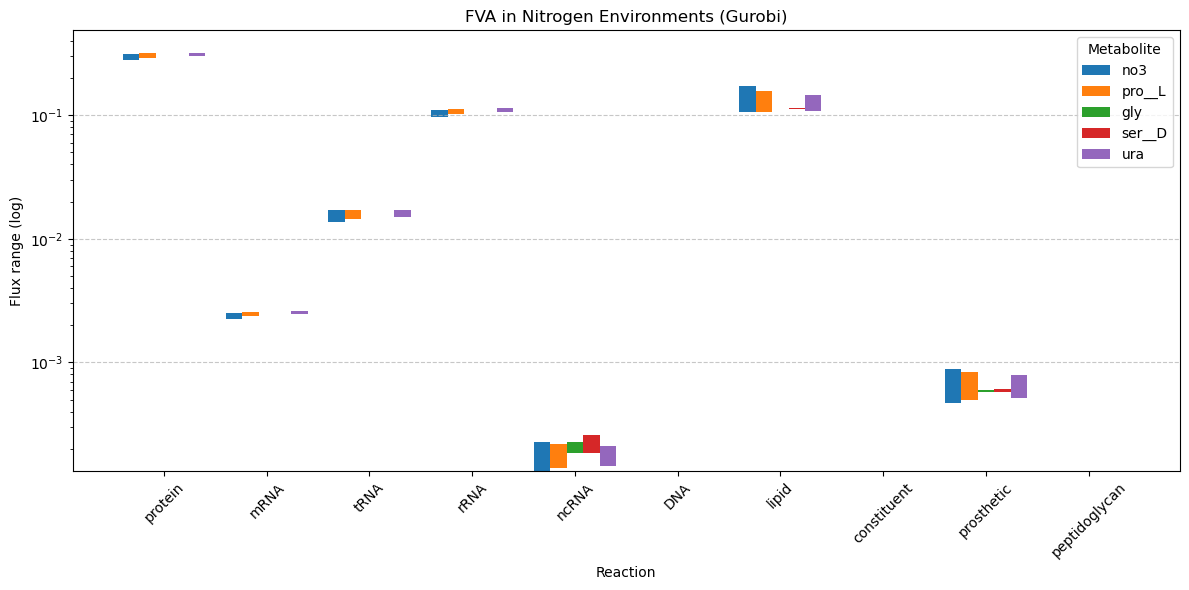

In [147]:
plot_fva(nitrogen_gurobi, 'FVA in Nitrogen Environments (Gurobi)')